# Economic and Affordability Features

**Purpose.** Examine the definition, provenance, transformation, grain, joined
completeness, distribution, outliers, redundancy, temporal alignment, retention
decision, and infographic use of the domain features.

This notebook is a diagnostic consumer of the `feature.*` semantic marts. Database
construction owns every feature transformation.

## Setup and authoritative feature definitions

In [1]:
from pathlib import Path
import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 120)
sns.set_theme(style="whitegrid")

ROOT = Path.cwd()
while not (ROOT / "data" / "quoll.duckdb").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
con = duckdb.connect(str(ROOT / "data" / "quoll.duckdb"), read_only=True)
FEATURE_TABLES = ['county_economic_annual']
EXCLUDED_CATALOG_FEATURES = ['accommodation_food_wage_share']
TABLE_NAMES = ", ".join("?" for _ in FEATURE_TABLES)

catalog = con.execute(
    f"SELECT * FROM feature.catalog "
    f"WHERE feature_table IN ({TABLE_NAMES}) "
    f"OR (feature_table IS NULL AND lower(category) = lower(?))"
    f"ORDER BY retained DESC, feature_table, feature_name",
    [*FEATURE_TABLES, 'Economic and Affordability'],
).df()
catalog = catalog.loc[
    ~catalog["feature_name"].isin(EXCLUDED_CATALOG_FEATURES)
].copy()
display(catalog)

,geographic_grain,retained,exclusion_reason,feature_table,feature_name,category,definition,unit,source_tables,transformation,temporal_grain,infographic_use
0,county,True,None,county_economic_annual,average_annual_wage_usd,Economic and affordability,Average annual wage across covered employment.,USD/worker/year,mart.statsamerica_cew_county_annual,County total-ownership CEW value joined on exa...,annual,Economic context
1,county,True,None,county_economic_annual,dividends_interest_rent_per_capita_usd,Economic and affordability,"BEA dividends, interest, and rent per resident.",USD/person/year,mart.statsamerica_bea_personal_income_annual,"BEA thousands of dollars multiplied by 1,000 a...",annual,"Feature comparison: Dividends, Interest, and R..."
2,county,True,None,county_economic_annual,earnings_by_place_of_work_per_capita_usd,Economic and affordability,BEA earnings by place of work per resident.,USD/person/year,mart.statsamerica_bea_personal_income_annual,"BEA thousands of dollars multiplied by 1,000 a...",annual,Feature comparison: Earnings by Place of Work ...
3,county,True,None,county_economic_annual,homeowners_insurance_pct_income,Economic and affordability,Estimated annual homeowners-insurance cost as ...,percent,mart.acs_county_affordability_annual,Weighted midpoint across ACS B25141 insurance-...,annual,Feature comparison: Homeowners Insurance Share...
4,county,True,None,county_economic_annual,median_household_income_usd,Economic and affordability,Median annual household income.,USD/year,mart.acs_county_affordability_annual; mart.acs...,Coalesced ACS affordability and DP03 estimates...,annual,Feature comparison: Income
5,county,True,None,county_economic_annual,owner_cost_burden_30pct_plus_pct,Economic and affordability,Share of mortgaged owners spending at least 30...,percent,mart.acs_county_affordability_annual,Burdened mortgaged-owner households divided by...,annual,Feature comparison: Cost-Burdened Households
6,county,True,None,county_economic_annual,property_taxes_pct_income,Economic and affordability,Median annual real-estate taxes as a share of ...,percent,mart.acs_county_affordability_annual,ACS B25103 median real-estate taxes divided by...,annual,Feature comparison: Property Taxes Share of In...
7,county,True,None,county_economic_annual,transfer_receipts_per_capita_usd,Economic and affordability,Transfer receipts per resident.,USD/person/year,mart.statsamerica_bea_personal_income_annual,"Thousands of dollars multiplied by 1,000 and d...",annual,Feature comparison: Transfer Receipts per Capita
8,county,True,None,county_economic_annual,unemployment_rate_pct,Economic and affordability,Civilian labor-force unemployment rate.,percent,mart.acs_county_economic_annual,Numeric ACS DP03 percentage estimate.,annual,Feature comparison: Unemployment
9,county,True,None,county_economic_annual,utilities_pct_income,Economic and affordability,"Estimated annual electricity, gas, water/sewer...",percent,mart.acs_county_affordability_annual,Weighted midpoint estimates from ACS B25132-B2...,annual,Feature comparison: Utilities Share of Income


The catalog above is the answer key for definition, unit, source, transformation,
grain, retention/exclusion, and infographic use. The remaining sections test whether
the built data match those definitions.

## Geographic and temporal grain

In [2]:
inventory_rows = []
for table in FEATURE_TABLES:
    columns = con.execute(f"DESCRIBE feature.{table}").df()["column_name"].tolist()
    time_column = next((c for c in ["year", "climate_month", "housing_month"] if c in columns), None)
    time_sql = (
        f"min({time_column}) AS min_time, max({time_column}) AS max_time, "
        f"count(DISTINCT {time_column}) AS periods"
        if time_column else
        "NULL AS min_time, NULL AS max_time, NULL AS periods"
    )
    row = con.execute(
        f"SELECT count(*) AS rows, count(DISTINCT fips) AS counties, {time_sql} "
        f"FROM feature.{table}"
    ).df()
    row.insert(0, "feature_table", table)
    inventory_rows.append(row)
inventory = pd.concat(inventory_rows, ignore_index=True)
display(inventory)

,feature_table,rows,counties,min_time,max_time,periods
0,county_economic_annual,41936,3237,2012,2024,13


## Completeness after joins

In [3]:
completeness_frames = []
for table in FEATURE_TABLES:
    schema = con.execute(f"DESCRIBE feature.{table}").df()
    has_year = "year" in schema["column_name"].tolist()
    numeric_columns = schema.loc[
        schema["column_type"].str.contains(
            "DOUBLE|FLOAT|DECIMAL|INTEGER|BIGINT|HUGEINT", case=False, regex=True
        ),
        "column_name",
    ].tolist()
    feature_columns = [
        column for column in numeric_columns
        if column not in {"year", "month"} and not column.endswith("_count")
    ]
    row_count = con.execute(f"SELECT count(*) FROM feature.{table}").fetchone()[0]
    rows = []
    for column in feature_columns:
        if has_year:
            present, first_year, last_year = con.execute(
                f'SELECT count("{column}"), '
                f'min(year) FILTER (WHERE "{column}" IS NOT NULL), '
                f'max(year) FILTER (WHERE "{column}" IS NOT NULL) '
                f"FROM feature.{table}"
            ).fetchone()
            in_scope_rows = con.execute(
                f"SELECT count(*) FROM feature.{table} "
                f"WHERE year BETWEEN ? AND ?",
                [first_year, last_year],
            ).fetchone()[0] if first_year is not None and last_year is not None else 0
        else:
            present = con.execute(
                f'SELECT count("{column}") FROM feature.{table}'
            ).fetchone()[0]
            first_year = last_year = None
            in_scope_rows = row_count
        rows.append({
            "feature_table": table, "feature_name": column,
            "non_null_rows": present, "total_rows": row_count,
            "global_complete_pct": present / row_count * 100 if row_count else np.nan,
            "first_observed_year": first_year,
            "last_observed_year": last_year,
            "in_scope_rows": in_scope_rows,
            "in_scope_complete_pct": (
                present / in_scope_rows * 100 if in_scope_rows else np.nan
            ),
        })
    completeness_frames.append(pd.DataFrame(rows))
completeness = pd.concat(completeness_frames, ignore_index=True)
display(completeness.sort_values(["feature_table", "global_complete_pct"]))

,feature_table,feature_name,non_null_rows,total_rows,global_complete_pct,first_observed_year,last_observed_year,in_scope_rows,in_scope_complete_pct
8,county_economic_annual,homeowners_insurance_pct_income,6439,41936,15.354349,2023,2024,6456,99.736679
10,county_economic_annual,utilities_pct_income,12855,41936,30.653853,2021,2024,12915,99.535424
5,county_economic_annual,housing_cost_pct_income,25742,41936,61.384014,2017,2024,25815,99.717219
12,county_economic_annual,net_earnings_per_capita_usd,31134,41936,74.241702,2014,2023,32272,96.473723
13,county_economic_annual,earnings_by_place_of_work_per_capita_usd,31134,41936,74.241702,2014,2023,32272,96.473723
14,county_economic_annual,dividends_interest_rent_per_capita_usd,31134,41936,74.241702,2014,2023,32272,96.473723
15,county_economic_annual,transfer_receipts_per_capita_usd,31134,41936,74.241702,2014,2023,32272,96.473723
11,county_economic_annual,per_capita_personal_income_usd,31170,41936,74.327547,2014,2023,32272,96.585275
16,county_economic_annual,average_annual_wage_usd,31418,41936,74.918924,2015,2024,32267,97.368829
9,county_economic_annual,property_taxes_pct_income,32107,41936,76.561904,2015,2024,32267,99.504137


## Distributions, outliers, and implausible values

In [4]:
frames = []
for table in FEATURE_TABLES:
    schema = con.execute(f"DESCRIBE feature.{table}").df()
    numeric_columns = schema.loc[
        schema["column_type"].str.contains(
            "DOUBLE|FLOAT|DECIMAL|INTEGER|BIGINT|HUGEINT", case=False, regex=True
        ),
        "column_name",
    ].tolist()
    numeric_columns = [
        c for c in numeric_columns
        if c not in {"year", "month"} and not c.endswith("_count")
    ]
    if not numeric_columns:
        continue
    quoted = ", ".join(f'"{column}"' for column in numeric_columns)
    frame = con.execute(f"SELECT {quoted} FROM feature.{table}").df()
    description = frame.describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.99]).T.reset_index(
        names="feature_name"
    )
    description.insert(0, "feature_table", table)
    q1 = frame.quantile(0.25)
    q3 = frame.quantile(0.75)
    iqr = q3 - q1
    outlier_counts = ((frame.lt(q1 - 1.5 * iqr)) | (frame.gt(q3 + 1.5 * iqr))).sum()
    description["iqr_outlier_count"] = description["feature_name"].map(outlier_counts)
    description["review_flag"] = np.where(
        (description["min"] < 0)
        & description["feature_name"].str.contains(
            "income|wage|population|price|value|precipitation|score", case=False
        ),
        "negative value requires review",
        np.where(description["iqr_outlier_count"] > 0, "distribution has IQR outliers", "none"),
    )
    frames.append(description)
distributions = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
display(distributions)

,feature_table,feature_name,count,mean,std,min,1%,25%,50%,75%,99%,max,iqr_outlier_count,review_flag
0,county_economic_annual,median_household_income_usd,41862.0,5.290180e+04,1.683348e+04,1.049900e+04,17781.830000,41929.000000,50657.000000,61219.000000,107228.920000,1.817650e+05,1299,distribution has IQR outliers
1,county_economic_annual,unemployment_rate_pct,32207.0,5.958552e+00,3.534200e+00,0.000000e+00,0.600000,3.800000,5.300000,7.200000,20.000000,4.090000e+01,1453,distribution has IQR outliers
2,county_economic_annual,median_home_value_usd,41834.0,1.582501e+05,1.045309e+05,1.870000e+04,54333.000000,95700.000000,129100.000000,182400.000000,578235.000000,1.633900e+06,2739,distribution has IQR outliers
3,county_economic_annual,median_gross_rent_usd_month,41869.0,-8.590522e+05,2.392681e+07,-6.666667e+08,395.000000,610.000000,713.000000,865.000000,1718.640000,2.922000e+03,2348,distribution has IQR outliers
4,county_economic_annual,median_owner_costs_mortgage_usd_month,41869.0,-1.001879e+06,2.584114e+07,-6.666667e+08,720.000000,1000.000000,1161.000000,1385.000000,2730.000000,4.001000e+03,2260,distribution has IQR outliers
5,county_economic_annual,housing_cost_pct_income,25741.0,1.439836e+01,3.212460e+00,4.214133e+00,8.468965,12.398524,14.190805,16.111010,22.224024,1.786315e+02,397,distribution has IQR outliers
6,county_economic_annual,owner_cost_burden_30pct_plus_pct,32183.0,2.663006e+01,8.012277e+00,0.000000e+00,10.926116,21.306320,25.469153,30.880016,50.247579,1.000000e+02,959,distribution has IQR outliers
7,county_economic_annual,median_property_taxes_usd_year,32110.0,1.624444e+03,1.281599e+03,1.990000e+02,237.000000,819.000000,1305.000000,1968.000000,6926.660000,1.000100e+04,1922,distribution has IQR outliers
8,county_economic_annual,homeowners_insurance_pct_income,6439.0,1.848101e+00,4.767232e-01,9.756098e-02,0.645901,1.535252,1.815092,2.157482,3.072236,4.427981e+00,116,distribution has IQR outliers
9,county_economic_annual,property_taxes_pct_income,32107.0,2.762218e+00,1.470682e+00,2.363533e-01,0.723259,1.770472,2.458751,3.358025,8.012271,1.791651e+01,1383,distribution has IQR outliers


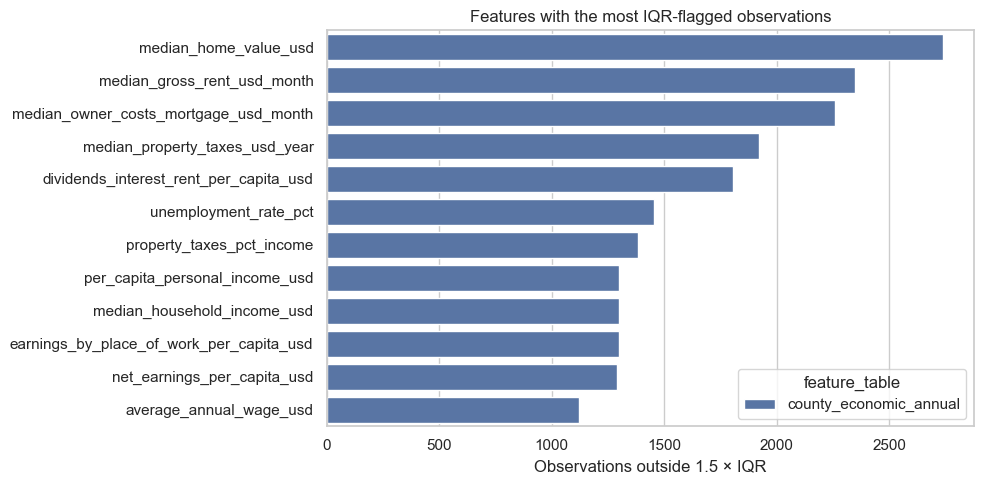

In [5]:
plot_data = distributions.sort_values("iqr_outlier_count", ascending=False).head(12)
if not plot_data.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=plot_data, y="feature_name", x="iqr_outlier_count", hue="feature_table", ax=ax)
    ax.set_title("Features with the most IQR-flagged observations")
    ax.set_xlabel("Observations outside 1.5 × IQR")
    ax.set_ylabel("")
    plt.tight_layout()
    plt.show()

## Redundancy among related features

In [6]:
correlation_frames = []
for table in FEATURE_TABLES:
    schema = con.execute(f"DESCRIBE feature.{table}").df()
    numeric_columns = schema.loc[
        schema["column_type"].str.contains("DOUBLE|FLOAT|DECIMAL", case=False, regex=True),
        "column_name",
    ].tolist()
    if len(numeric_columns) < 2:
        continue
    quoted = ", ".join(f'"{column}"' for column in numeric_columns)
    frame = con.execute(f"SELECT {quoted} FROM feature.{table}").df()
    corr = frame.corr(min_periods=100)
    pairs = (
        corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        .stack()
        .rename("correlation")
        .reset_index()
        .rename(columns={"level_0": "feature_a", "level_1": "feature_b"})
    )
    pairs.insert(0, "feature_table", table)
    correlation_frames.append(pairs)
correlations = pd.concat(correlation_frames, ignore_index=True) if correlation_frames else pd.DataFrame()
if not correlations.empty:
    correlations["absolute_correlation"] = correlations["correlation"].abs()
    display(correlations.sort_values("absolute_correlation", ascending=False).head(30))
else:
    display(pd.DataFrame({"result": ["Fewer than two continuous features were available."]}))

,feature_table,feature_a,feature_b,correlation,absolute_correlation
92,county_economic_annual,median_property_taxes_usd_year,property_taxes_pct_income,0.892099,0.892099
121,county_economic_annual,per_capita_personal_income_usd,net_earnings_per_capita_usd,0.889674,0.889674
9,county_economic_annual,median_household_income_usd,utilities_pct_income,-0.865281,0.865281
123,county_economic_annual,per_capita_personal_income_usd,dividends_interest_rent_per_capita_usd,0.781230,0.781230
11,county_economic_annual,median_household_income_usd,net_earnings_per_capita_usd,0.774289,0.774289
1,county_economic_annual,median_household_income_usd,median_home_value_usd,0.734099,0.734099
10,county_economic_annual,median_household_income_usd,per_capita_personal_income_usd,0.712908,0.712908
6,county_economic_annual,median_household_income_usd,median_property_taxes_usd_year,0.703036,0.703036
15,county_economic_annual,median_household_income_usd,average_annual_wage_usd,0.664659,0.664659
35,county_economic_annual,median_home_value_usd,median_property_taxes_usd_year,0.658024,0.658024


## Temporal alignment

In [7]:
alignment_frames = []
for table in FEATURE_TABLES:
    columns = con.execute(f"DESCRIBE feature.{table}").df()["column_name"].tolist()
    time_column = next((c for c in ["year", "climate_month", "housing_month"] if c in columns), None)
    flags = [c for c in columns if c.startswith("has_")]
    if time_column and flags:
        aggregates = ", ".join(
            f'avg(cast("{flag}" AS INTEGER)) * 100 AS "{flag}_pct"' for flag in flags
        )
        alignment = con.execute(
            f"SELECT {time_column}, count(DISTINCT fips) AS counties, {aggregates} "
            f"FROM feature.{table} GROUP BY {time_column} ORDER BY {time_column}"
        ).df()
        alignment.insert(0, "feature_table", table)
        alignment_frames.append(alignment)
    elif time_column:
        alignment = con.execute(
            f"SELECT {time_column}, count(DISTINCT fips) AS counties "
            f"FROM feature.{table} GROUP BY {time_column} ORDER BY {time_column}"
        ).df()
        alignment.insert(0, "feature_table", table)
        alignment_frames.append(alignment)
alignment = pd.concat(alignment_frames, ignore_index=True) if alignment_frames else pd.DataFrame()
display(alignment)

,feature_table,year,counties,has_acs_affordability_pct,has_acs_economic_pct,has_bea_pct,has_cew_pct
0,county_economic_annual,2012,3221,100.000000,0.000000,0.000000,0.000000
1,county_economic_annual,2013,3221,100.000000,0.000000,0.000000,0.000000
2,county_economic_annual,2014,3227,99.783080,0.000000,96.591261,0.000000
3,county_economic_annual,2015,3227,99.783080,99.783080,96.591261,97.396963
4,county_economic_annual,2016,3225,99.844961,99.844961,96.651163,97.395349
5,county_economic_annual,2017,3225,99.844961,99.844961,96.651163,97.395349
6,county_economic_annual,2018,3225,99.844961,99.844961,96.651163,97.395349
7,county_economic_annual,2019,3225,99.844961,99.844961,96.651163,97.395349
8,county_economic_annual,2020,3225,99.875969,99.875969,96.651163,97.426357
9,county_economic_annual,2021,3225,99.875969,99.875969,96.651163,97.426357


## Retention and infographic use

Retention is decided in `feature.catalog`, not from visual inspection in this
notebook. A feature is retained when its definition is interpretable, its unit and
grain are stable, its completeness is adequate for its intended comparison, and it
does not duplicate the outcome or a stronger related measure. The `infographic_use`
and `exclusion_reason` catalog fields record the current decision.

In [8]:
display(catalog[[
    "feature_name", "retained", "exclusion_reason", "infographic_use",
    "source_tables", "transformation"
]])
con.close()

,feature_name,retained,exclusion_reason,infographic_use,source_tables,transformation
0,average_annual_wage_usd,True,None,Economic context,mart.statsamerica_cew_county_annual,County total-ownership CEW value joined on exa...
1,dividends_interest_rent_per_capita_usd,True,None,"Feature comparison: Dividends, Interest, and R...",mart.statsamerica_bea_personal_income_annual,"BEA thousands of dollars multiplied by 1,000 a..."
2,earnings_by_place_of_work_per_capita_usd,True,None,Feature comparison: Earnings by Place of Work ...,mart.statsamerica_bea_personal_income_annual,"BEA thousands of dollars multiplied by 1,000 a..."
3,homeowners_insurance_pct_income,True,None,Feature comparison: Homeowners Insurance Share...,mart.acs_county_affordability_annual,Weighted midpoint across ACS B25141 insurance-...
4,median_household_income_usd,True,None,Feature comparison: Income,mart.acs_county_affordability_annual; mart.acs...,Coalesced ACS affordability and DP03 estimates...
5,owner_cost_burden_30pct_plus_pct,True,None,Feature comparison: Cost-Burdened Households,mart.acs_county_affordability_annual,Burdened mortgaged-owner households divided by...
6,property_taxes_pct_income,True,None,Feature comparison: Property Taxes Share of In...,mart.acs_county_affordability_annual,ACS B25103 median real-estate taxes divided by...
7,transfer_receipts_per_capita_usd,True,None,Feature comparison: Transfer Receipts per Capita,mart.statsamerica_bea_personal_income_annual,"Thousands of dollars multiplied by 1,000 and d..."
8,unemployment_rate_pct,True,None,Feature comparison: Unemployment,mart.acs_county_economic_annual,Numeric ACS DP03 percentage estimate.
9,utilities_pct_income,True,None,Feature comparison: Utilities Share of Income,mart.acs_county_affordability_annual,Weighted midpoint estimates from ACS B25132-B2...
